In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, auc
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay

import pickle

#pd.set_option('display.max_rows',500)
pd.set_option('display.max_columns',500)

In [12]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [14]:
# Load cleaned dataset
df = pd.read_csv(r'C:\Users\ameen\Lung Cancer Risk Prediction\Lung_Cancer_Cleaned.csv')

## Data Preprocessing

In [16]:
#  Check target class distribution
print("\nTarget class distribution:\n", df['PULMONARY_DISEASE'].value_counts())


Target class distribution:
 PULMONARY_DISEASE
NO     2963
YES    2037
Name: count, dtype: int64


In [18]:
# === Feature Engineering ===

# Separate features and target
y = df['PULMONARY_DISEASE']
X = df.drop('PULMONARY_DISEASE', axis=1)

In [20]:
# Label Encoding for binary categorical columns
label_enc_cols = [
    'GENDER', 'SMOKING', 'FINGER_DISCOLORATION', 'MENTAL_STRESS',
    'EXPOSURE_TO_POLLUTION', 'LONG_TERM_ILLNESS', 'IMMUNE_WEAKNESS',
    'BREATHING_ISSUE', 'ALCOHOL_CONSUMPTION', 'THROAT_DISCOMFORT',
    'CHEST_TIGHTNESS', 'FAMILY_HISTORY', 'SMOKING_FAMILY_HISTORY', 'STRESS_IMMUNE'
]

le = LabelEncoder()
for col in label_enc_cols:
    X[col] = le.fit_transform(X[col])

In [22]:
# Encode target column
y = le.fit_transform(y)

In [24]:
# Encode target if it's not numeric
if y.dtype == 'object':
    y = y.astype('category').cat.codes

In [26]:
# Standardize continuous features
scaler = StandardScaler()
continuous_cols = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Preview final features
print("\nEncoded and Scaled Features:")
print(X.head())


Encoded and Scaled Features:
        AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0  0.682203       1        1                     1              1   
1  1.505110       1        1                     0              0   
2  0.049197       1        1                     0              0   
3 -0.837011       0        1                     0              1   
4  0.935405       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0      0.353770                0   
1                      1                  1     -0.927318                1   
2                      0                  0      0.574472                0   
3                      1                  0      0.600802                0   
4                      1                  1      0.594252                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURATION  \
0    

## Model Building and Evaluation

In [28]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [42]:
# Training & Evaluation

# Train Model
best_model = XGBClassifier(eval_metric='logloss', random_state=42)
best_model.fit(X_train, y_train)

# Predict
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# --- Evaluation Report ---
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       571
           1       0.87      0.87      0.87       429

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [68]:
# --- Column classification ---
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

In [70]:
# Results to DataFrame
results_df = pd.DataFrame(results)

In [72]:
# View sorted results
results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.916,0.905882,0.897436,0.901639,0.913692
0,Logistic Regression,0.910,0.880899,0.913753,0.897025,0.910467
2,XGBoost,0.892,0.874126,0.874126,0.874126,0.889777


In [48]:
# Choose the best model — replace "XGBoost" with whichever performed best in your case
best_model = XGBClassifier(eval_metric='logloss')
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # probability scores for ROC

In [50]:
# --- Save Model as Pickle ---
with open("lung_disease_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [54]:
print("Model trained and saved as 'lung_disease_model.pkl'")

Model trained and saved as 'lung_disease_model.pkl'


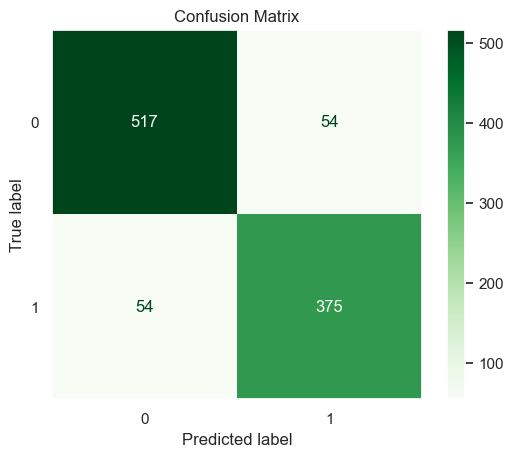

In [57]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

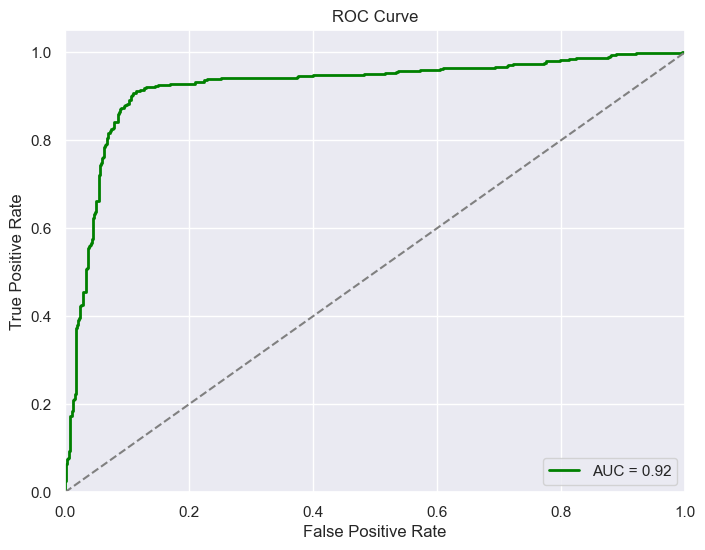

In [59]:
# --- AUC-ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [61]:
# Replace best_model with your actual trained model variable

with open("lung_disease_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

## Pipeline Setup

In [74]:
# --- Preprocessing steps ---
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [76]:
# Final pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(eval_metric='logloss', random_state=42))
])

In [78]:
# Train
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['AGE', 'GENDER', 'SMOKING', 'FINGER_DISCOLORATION', 'MENTAL_STRESS',
       'EXPOSURE_TO_POLLUTION', 'LONG_TERM_ILLNESS', 'ENERGY_LEVEL',
       'IMMUNE_WEAKNESS', 'BREATHING_ISSUE', 'ALCOHOL_CONSUMPTION',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [80]:
# Predict and evaluate
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       571
           1       0.87      0.87      0.87       429

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



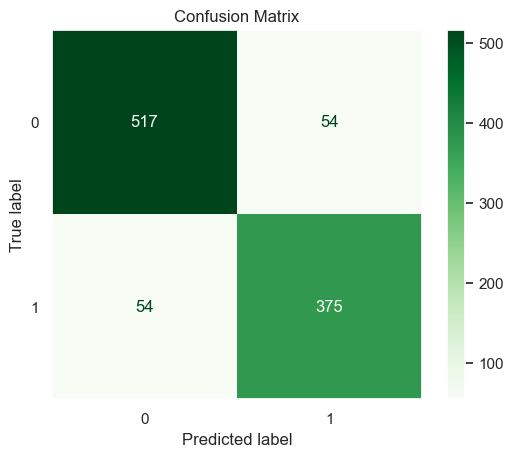

In [82]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

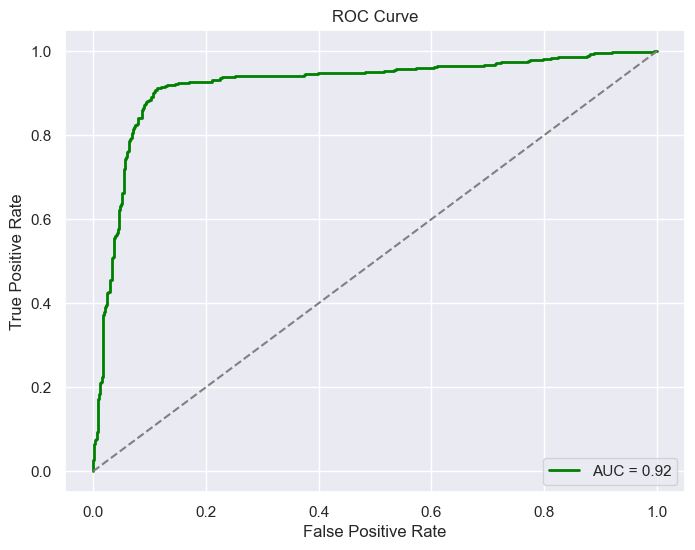

In [84]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [86]:
# Save full pipeline
with open("lung_disease_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Full pipeline saved as 'lung_disease_pipeline.pkl'")

Full pipeline saved as 'lung_disease_pipeline.pkl'
